Graph Setup

In [2]:
import networkx as nx

G = nx.read_edgelist("data/CA-AstroPh.txt", comments="#", nodetype=int)

# --- Controllo e rimozione dei self-loop ---
n_self_loops = nx.number_of_selfloops(G)
print(f"Self-loop trovati: {n_self_loops}")

if n_self_loops > 0:
    G.remove_edges_from(nx.selfloop_edges(G))
    print(f"Self-loop rimossi. Nuovo numero di archi: {G.number_of_edges()}")

# G ripulito.
# --- Componente connessa più grande ---

largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

Self-loop trovati: 60
Self-loop rimossi. Nuovo numero di archi: 198050


In [3]:
from algorithms.cost_functions import cost_random, cost_degree
from algorithms.variant.cs_greedy_new import cost_seeds_greedy
from algorithms.wtss import wtss
from algorithms.my_seeds import my_seeds
from algorithms.cascade import simulate_cascade

# Le due funzioni di costo, calcolate una sola volta su G_lcc
c1 = cost_random(G_lcc, low=1, high=21, seed=42)
c2 = cost_degree(G_lcc)

print(f"c1 - costo totale: {sum(c1.values())}, media: {sum(c1.values())/len(c1):.2f}")
print(f"c2 - costo totale: {sum(c2.values())}, media: {sum(c2.values())/len(c2):.2f}")

c1 - costo totale: 197720, media: 11.04
c2 - costo totale: 201526, media: 11.26


In [4]:
algorithms = {
    "Greedy-f1": lambda G, k, c: cost_seeds_greedy(G, k, c, "f1"),
    "Greedy-f2": lambda G, k, c: cost_seeds_greedy(G, k, c, "f2"),
    "Greedy-f3": lambda G, k, c: cost_seeds_greedy(G, k, c, "f3"),
    "WTSS":      lambda G, k, c: wtss(G, k, c),
    "My-Seeds":  lambda G, k, c: my_seeds(G, k, c),
}

percentages = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]

cost_scenarios = {
    "c1_random": c1,
    "c2_degree": c2,
}

k_values = {}
for cost_name, c in cost_scenarios.items():
    total_cost = sum(c.values())
    k_values[cost_name] = [round(p * total_cost) for p in percentages]
    print(f"{cost_name} (totale={total_cost}): k = {k_values[cost_name]}")

c1_random (totale=197720): k = [989, 1977, 3954, 9886, 19772, 39544]
c2_degree (totale=201526): k = [1008, 2015, 4031, 10076, 20153, 40305]


Esperimento 1

In [8]:
import time
import json
import os
import pandas as pd

# ============================================================
# ESPERIMENTO 1 — Variazione del budget k
# ============================================================

output_file = "results/results_experiment1.csv"

# Se il file esiste già, recupera i risultati precedenti.
# In questo modo, rilanciando la cella, non vengono ricalcolati
# gli esperimenti già completati.
if os.path.exists(output_file):
    results_df = pd.read_csv(output_file)
    results = results_df.to_dict("records")

    completed = {
        (row["cost_function"], row["algorithm"], float(row["percentage"]))
        for _, row in results_df.iterrows()
    }

    print(f"Risultati già presenti: {len(results)}")
else:
    results = []
    completed = set()


total_runs = len(cost_scenarios) * len(algorithms) * len(percentages)
run_number = len(completed)


for cost_name, c in cost_scenarios.items():

    total_cost = sum(c.values())

    print("\n" + "=" * 70)
    print(f"FUNZIONE DI COSTO: {cost_name}")
    print(f"Costo totale della rete: {total_cost}")
    print("=" * 70)

    for algorithm_name, algorithm in algorithms.items():

        print(f"\n--- {algorithm_name} ---")

        for percentage in percentages:

            key = (cost_name, algorithm_name, float(percentage))

            # Salta le esecuzioni già presenti nel CSV
            if key in completed:
                print(
                    f"[SKIP] k = {percentage * 100:g}% "
                    f"già calcolato"
                )
                continue

            k = round(percentage * total_cost)

            run_number += 1

            print(
                f"\n[{run_number}/{total_runs}] "
                f"{cost_name} | {algorithm_name} | "
                f"k = {percentage * 100:g}% ({k})"
            )

            # ------------------------------------------------
            # 1. Calcolo del seed set
            # ------------------------------------------------
            start = time.time()

            S = algorithm(G_lcc, k, c)

            runtime = time.time() - start

            # ------------------------------------------------
            # 2. Simulazione della Majority Cascade
            # ------------------------------------------------
            influenced = simulate_cascade(G_lcc, S)

            # ------------------------------------------------
            # 3. Statistiche
            # ------------------------------------------------
            seed_cost = sum(c[v] for v in S)
            seed_size = len(S)
            influenced_size = len(influenced)

            print(
                f"|S| = {seed_size} | "
                f"c(S) = {seed_cost}/{k} | "
                f"|Inf[G,S]| = {influenced_size} | "
                f"tempo = {runtime:.2f}s"
            )

            # ------------------------------------------------
            # 4. Salvataggio risultato
            # ------------------------------------------------
            result = {
                "cost_function": cost_name,
                "algorithm": algorithm_name,
                "percentage": percentage,
                "percentage_label": f"{percentage * 100:g}%",
                "k": k,
                "seed_size": seed_size,
                "seed_cost": seed_cost,
                "influenced_size": influenced_size,
                "runtime_seconds": runtime,

                # Salviamo anche i nodi del seed set:
                # serviranno negli Esperimenti 2 e 3.
                "seed_set": json.dumps(sorted(S))
            }

            results.append(result)
            completed.add(key)

            # Salvataggio incrementale dopo OGNI esecuzione
            pd.DataFrame(results).to_csv(output_file, index=False)


print("\n" + "=" * 70)
print("ESPERIMENTO 1 COMPLETATO")
print(f"Risultati salvati in: {output_file}")
print("=" * 70)

results_df = pd.DataFrame(results)

display(
    results_df[
        [
            "cost_function",
            "algorithm",
            "percentage_label",
            "k",
            "seed_size",
            "seed_cost",
            "influenced_size",
            "runtime_seconds"
        ]
    ]
)

Risultati già presenti: 60

FUNZIONE DI COSTO: c1_random
Costo totale della rete: 197720

--- Greedy-f1 ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già calcolato
[SKIP] k = 20% già calcolato

--- Greedy-f2 ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già calcolato
[SKIP] k = 20% già calcolato

--- Greedy-f3 ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già calcolato
[SKIP] k = 20% già calcolato

--- WTSS ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già calcolato
[SKIP] k = 20% già calcolato

--- My-Seeds ---
[SKIP] k = 0.5% già calcolato
[SKIP] k = 1% già calcolato
[SKIP] k = 2% già calcolato
[SKIP] k = 5% già calcolato
[SKIP] k = 10% già c

,cost_function,algorithm,percentage_label,k,seed_size,seed_cost,influenced_size,runtime_seconds
0,c1_random,Greedy-f1,0.5%,989,435,987,633,33.213625
1,c1_random,Greedy-f1,1%,1977,697,1973,1126,50.413544
2,c1_random,Greedy-f1,2%,3954,1128,3948,13582,79.704099
3,c1_random,Greedy-f1,5%,9886,2146,9873,14598,139.323867
4,c1_random,Greedy-f1,10%,19772,3696,19772,16530,224.584368
5,c1_random,Greedy-f1,20%,39544,6166,39540,17767,329.131108
6,c1_random,Greedy-f2,0.5%,989,388,989,540,123.590172
7,c1_random,Greedy-f2,1%,1977,640,1976,1071,217.109263
8,c1_random,Greedy-f2,2%,3954,1074,3953,13260,406.722128
9,c1_random,Greedy-f2,5%,9886,2133,9884,14352,917.681943


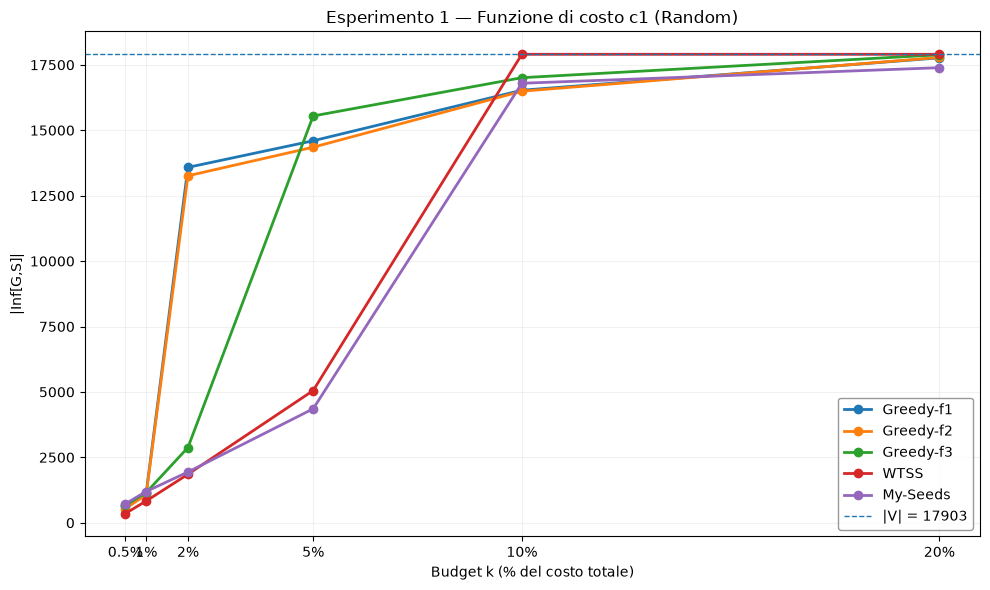

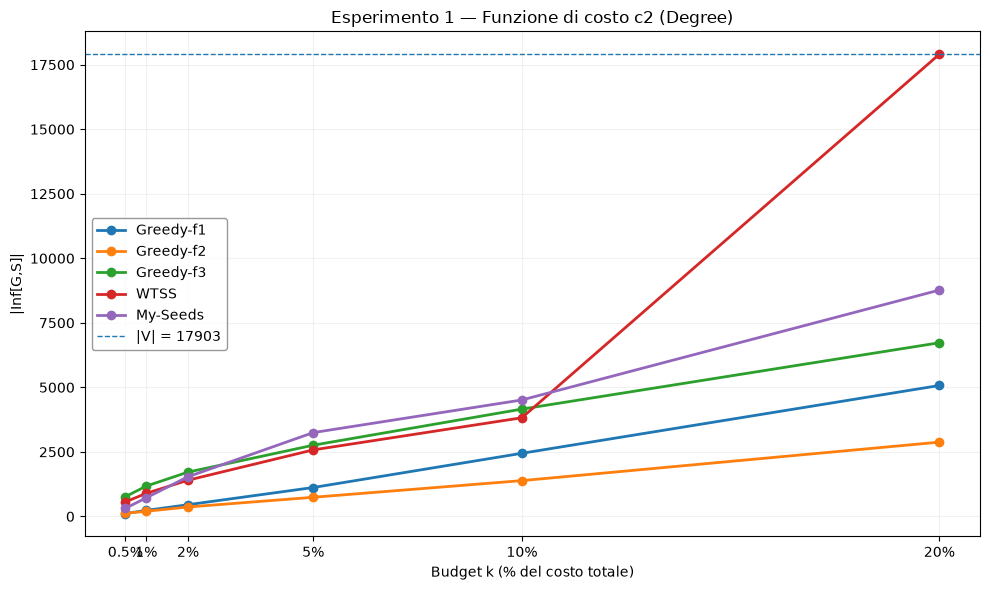

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "legend.facecolor": "white",
    "legend.edgecolor": "gray",
})
# ============================================================
# GRAFICI ESPERIMENTO 1
# ============================================================

results_exp1 = pd.read_csv("results/results_experiment1.csv")

cost_titles = {
    "c1_random": "Esperimento 1 — Funzione di costo c1 (Random)",
    "c2_degree": "Esperimento 1 — Funzione di costo c2 (Degree)"
}

algorithm_order = [
    "Greedy-f1",
    "Greedy-f2",
    "Greedy-f3",
    "WTSS",
    "My-Seeds"
]

# Percentuali espresse come 0.5, 1, 2, 5, 10, 20
budget_ticks = sorted(results_exp1["percentage"].unique() * 100)


for cost_name in ["c1_random", "c2_degree"]:

    df_cost = results_exp1[
        results_exp1["cost_function"] == cost_name
    ]

    plt.figure(figsize=(10, 6))

    for algorithm in algorithm_order:

        df_alg = df_cost[
            df_cost["algorithm"] == algorithm
        ].sort_values("percentage")

        plt.plot(
            df_alg["percentage"] * 100,
            df_alg["influenced_size"],
            marker="o",
            linewidth=2,
            label=algorithm
        )

    # Numero massimo di nodi potenzialmente attivabili
    plt.axhline(
        y=G_lcc.number_of_nodes(),
        linestyle="--",
        linewidth=1,
        label=f"|V| = {G_lcc.number_of_nodes()}"
    )

    plt.title(cost_titles[cost_name])
    plt.xlabel("Budget k (% del costo totale)")
    plt.ylabel("|Inf[G,S]|")

    plt.xticks(
        budget_ticks,
        [f"{x:g}%" for x in budget_ticks]
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Salvataggio del grafico
    plt.savefig(
        f"experiment1_{cost_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

Esperimento 2

In [5]:
import pandas as pd
import json
import random

# ============================================================
# ESPERIMENTO 2 — Robustezza alla rimozione casuale di archi
# ============================================================

# Budget rappresentativo scelto dall'Esperimento 1.
# MODIFICARE questo valore dopo aver analizzato i risultati.
k_star_percentage = 0.10       # esempio: 5%

# Percentuali di archi da rimuovere
edge_removal_percentages = [0.01, 0.05, 0.10, 0.20]

# Seed per rendere riproducibile la perturbazione casuale
random_seed = 42

input_file = "results/results_experiment1.csv"
output_file = "results/results_experiment2.csv"


# ------------------------------------------------------------
# 1. Caricamento dei risultati dell'Esperimento 1
# ------------------------------------------------------------

exp1_df = pd.read_csv(input_file)

# Seleziona soltanto i risultati corrispondenti a k*
exp1_kstar = exp1_df[
    (exp1_df["percentage"] - k_star_percentage).abs() < 1e-12
].copy()

expected_results = len(cost_scenarios) * len(algorithms)

if len(exp1_kstar) != expected_results:
    raise ValueError(
        f"Per k*={k_star_percentage * 100:g}% erano attesi "
        f"{expected_results} seed set, ma ne sono stati trovati "
        f"{len(exp1_kstar)}."
    )

print(
    f"k* selezionato: {k_star_percentage * 100:g}% "
    f"({len(exp1_kstar)} seed set recuperati)"
)


# ------------------------------------------------------------
# 2. Funzione per creare un grafo perturbato
#
# ------------------------------------------------------------

# ------------------------------------------------------------
# 2. Generazione CUMULATIVA dei grafi perturbati
#
# Gli archi rimossi sono annidati:
# E_1% ⊂ E_5% ⊂ E_10% ⊂ E_20%
#
# Le percentuali sono sempre riferite al numero di archi
# del grafo originale G_lcc.
# ------------------------------------------------------------

rng = random.Random(random_seed)

# Un solo ordine casuale degli archi per tutto l'esperimento
edge_order = list(G_lcc.edges())
rng.shuffle(edge_order)

# Grafo che viene progressivamente perturbato
G_working = G_lcc.copy()

removed_edges = []
edge_index = 0

perturbed_graphs = {}

original_edge_count = G_lcc.number_of_edges()


for percentage in edge_removal_percentages:

    target_remove = round(
        percentage * original_edge_count
    )

    # Continuiamo a rimuovere archi finché non raggiungiamo
    # il numero totale previsto per questa percentuale.
    while len(removed_edges) < target_remove:

        if edge_index >= len(edge_order):
            raise RuntimeError(
                f"Non è stato possibile raggiungere "
                f"{percentage * 100:g}% di archi rimossi "
                f"senza creare nodi isolati."
            )

        u, v = edge_order[edge_index]
        edge_index += 1

        # L'arco potrebbe essere già stato rimosso
        if not G_working.has_edge(u, v):
            continue

        # Evitiamo di creare nodi isolati
        if (
            G_working.degree(u) > 1
            and G_working.degree(v) > 1
        ):
            G_working.remove_edge(u, v)
            removed_edges.append((u, v))

    # Salviamo una fotografia del grafo a questa percentuale
    G_snapshot = G_working.copy()

    n_components = nx.number_connected_components(G_snapshot)
    n_isolates = nx.number_of_isolates(G_snapshot)

    print(
        f"{percentage * 100:g}%: "
        f"{len(removed_edges)} archi rimossi | "
        f"archi rimanenti = {G_snapshot.number_of_edges()} | "
        f"componenti = {n_components} | "
        f"nodi isolati = {n_isolates}"
    )

    perturbed_graphs[percentage] = {
        "graph": G_snapshot,

        # Copia necessaria: altrimenti tutte le entry
        # punterebbero alla stessa lista che continua a crescere
        "removed_edges": list(removed_edges)
    }

# ------------------------------------------------------------
# 3. Esecuzione dell'Esperimento 2
# ------------------------------------------------------------

results_exp2 = []

total_runs = (
    len(edge_removal_percentages)
    * len(cost_scenarios)
    * len(algorithms)
)

run_number = 0


for percentage in edge_removal_percentages:

    G_removed = perturbed_graphs[percentage]["graph"]
    removed_edges = perturbed_graphs[percentage]["removed_edges"]

    print("\n" + "=" * 70)
    print(
        f"RIMOZIONE ARCHI: {percentage * 100:g}% "
        f"({len(removed_edges)} archi)"
    )
    print("=" * 70)

    for _, row in exp1_kstar.iterrows():

        run_number += 1

        cost_name = row["cost_function"]
        algorithm_name = row["algorithm"]

        # Recupero del seed set calcolato nell'Esperimento 1
        S = set(json.loads(row["seed_set"]))

        # ----------------------------------------------------
        # Simulazione della cascata sul grafo perturbato
        # ----------------------------------------------------

        influenced = simulate_cascade(G_removed, S)

        influenced_size = len(influenced)

        print(
            f"[{run_number}/{total_runs}] "
            f"{cost_name} | {algorithm_name} | "
            f"|S|={len(S)} | "
            f"|Inf[G',S]|={influenced_size}"
        )

        results_exp2.append({
            "cost_function": cost_name,
            "algorithm": algorithm_name,

            "k_star_percentage": k_star_percentage,
            "k_star_percentage_label":
                f"{k_star_percentage * 100:g}%",

            "edge_removal_percentage": percentage,
            "edge_removal_label":
                f"{percentage * 100:g}%",

            "removed_edges": len(removed_edges),
            "remaining_edges": G_removed.number_of_edges(),

            "seed_size": len(S),

            "influenced_original":
                row["influenced_size"],

            "influenced_after_removal":
                influenced_size,

            "is_connected": nx.is_connected(G_removed),

            "number_of_components":
                nx.number_connected_components(G_removed),

            "isolated_nodes":
                nx.number_of_isolates(G_removed),

            # Per riproducibilità salviamo anche quali archi
            # sono stati effettivamente rimossi
            "removed_edge_list":
                json.dumps(removed_edges)
        })


# ------------------------------------------------------------
# 4. Salvataggio CSV
# ------------------------------------------------------------

results_exp2_df = pd.DataFrame(results_exp2)

results_exp2_df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("ESPERIMENTO 2 COMPLETATO")
print(f"Risultati salvati in: {output_file}")
print("=" * 70)

display(
    results_exp2_df[
        [
            "cost_function",
            "algorithm",
            "edge_removal_label",
            "removed_edges",
            "seed_size",
            "influenced_original",
            "influenced_after_removal",
            "is_connected",
            "number_of_components",
            "isolated_nodes"
        ]
    ]
)

k* selezionato: 10% (10 seed set recuperati)
1%: 1970 archi rimossi | archi rimanenti = 195002 | componenti = 2 | nodi isolati = 0
5%: 9849 archi rimossi | archi rimanenti = 187123 | componenti = 5 | nodi isolati = 0
10%: 19697 archi rimossi | archi rimanenti = 177275 | componenti = 8 | nodi isolati = 0
20%: 39394 archi rimossi | archi rimanenti = 157578 | componenti = 22 | nodi isolati = 0

RIMOZIONE ARCHI: 1% (1970 archi)
[1/40] c1_random | Greedy-f1 | |S|=3696 | |Inf[G',S]|=16539
[2/40] c1_random | Greedy-f2 | |S|=3727 | |Inf[G',S]|=16501
[3/40] c1_random | Greedy-f3 | |S|=3806 | |Inf[G',S]|=16968
[4/40] c1_random | WTSS | |S|=3264 | |Inf[G',S]|=17894
[5/40] c1_random | My-Seeds | |S|=4200 | |Inf[G',S]|=16845
[6/40] c2_degree | Greedy-f1 | |S|=1807 | |Inf[G',S]|=2463
[7/40] c2_degree | Greedy-f2 | |S|=1327 | |Inf[G',S]|=1389
[8/40] c2_degree | Greedy-f3 | |S|=2666 | |Inf[G',S]|=4176
[9/40] c2_degree | WTSS | |S|=3289 | |Inf[G',S]|=3825
[10/40] c2_degree | My-Seeds | |S|=4236 | |Inf[

,cost_function,algorithm,edge_removal_label,removed_edges,seed_size,influenced_original,influenced_after_removal,is_connected,number_of_components,isolated_nodes
0,c1_random,Greedy-f1,1%,1970,3696,16530,16539,False,2,0
1,c1_random,Greedy-f2,1%,1970,3727,16492,16501,False,2,0
2,c1_random,Greedy-f3,1%,1970,3806,17009,16968,False,2,0
3,c1_random,WTSS,1%,1970,3264,17903,17894,False,2,0
4,c1_random,My-Seeds,1%,1970,4200,16796,16845,False,2,0
5,c2_degree,Greedy-f1,1%,1970,1807,2445,2463,False,2,0
6,c2_degree,Greedy-f2,1%,1970,1327,1386,1389,False,2,0
7,c2_degree,Greedy-f3,1%,1970,2666,4157,4176,False,2,0
8,c2_degree,WTSS,1%,1970,3289,3822,3825,False,2,0
9,c2_degree,My-Seeds,1%,1970,4236,4511,4504,False,2,0


In [5]:
import pandas as pd
import json
import math

# ============================================================
# ANALISI STRUTTURALE ESPERIMENTO 2
# Effetto della rimozione degli archi sulle soglie majority
# ============================================================

exp2 = pd.read_csv("results/results_experiment2.csv")

# ------------------------------------------------------------
# Valori del grafo originale
# ------------------------------------------------------------

original_degree = dict(G_lcc.degree())

# Soglia effettiva del Majority Cascade:
# degree/2 nel codice è equivalente a ceil(degree/2)
# perché il numero di vicini attivi è sempre intero.
original_threshold = {
    v: math.ceil(original_degree[v] / 2)
    for v in G_lcc.nodes()
}

original_avg_degree = (
    sum(original_degree.values()) / G_lcc.number_of_nodes()
)

original_avg_threshold = (
    sum(original_threshold.values()) / G_lcc.number_of_nodes()
)


analysis_rows = []

# ------------------------------------------------------------
# Punto 0% — grafo originale
# ------------------------------------------------------------

analysis_rows.append({
    "removed_edges_percentage": 0,
    "removed_edges": 0,
    "remaining_edges": G_lcc.number_of_edges(),
    "average_degree": original_avg_degree,
    "average_threshold": original_avg_threshold,
    "nodes_threshold_decreased": 0,
    "threshold_decreased_percentage": 0.0,
    "average_threshold_reduction": 0.0,
    "number_of_components": nx.number_connected_components(G_lcc),
    "isolated_nodes": nx.number_of_isolates(G_lcc)
})


# ------------------------------------------------------------
# Recuperiamo UNA sola riga per ogni percentuale.
#
# La lista di archi rimossi è infatti la stessa per tutti
# gli algoritmi e per entrambe le funzioni di costo.
# ------------------------------------------------------------

perturbations = (
    exp2
    .sort_values("edge_removal_percentage")
    .drop_duplicates(subset="edge_removal_percentage")
)


for _, row in perturbations.iterrows():

    percentage = row["edge_removal_percentage"]

    # Recupero degli archi rimossi dal CSV
    removed_edges = json.loads(row["removed_edge_list"])

    # Ricostruzione del grafo perturbato
    G_removed = G_lcc.copy()
    G_removed.remove_edges_from(removed_edges)

    # --------------------------------------------------------
    # Gradi e soglie sul nuovo grafo
    # --------------------------------------------------------

    new_degree = dict(G_removed.degree())

    new_threshold = {
        v: math.ceil(new_degree[v] / 2)
        for v in G_removed.nodes()
    }

    avg_degree = (
        sum(new_degree.values()) / G_removed.number_of_nodes()
    )

    avg_threshold = (
        sum(new_threshold.values()) / G_removed.number_of_nodes()
    )

    # --------------------------------------------------------
    # Nodi la cui soglia è diminuita
    # --------------------------------------------------------

    nodes_threshold_decreased = sum(
        1
        for v in G_removed.nodes()
        if new_threshold[v] < original_threshold[v]
    )

    threshold_decreased_percentage = (
        nodes_threshold_decreased
        / G_removed.number_of_nodes()
        * 100
    )

    # Riduzione media della soglia su tutti i nodi
    average_threshold_reduction = sum(
        original_threshold[v] - new_threshold[v]
        for v in G_removed.nodes()
    ) / G_removed.number_of_nodes()

    analysis_rows.append({
        "removed_edges_percentage": percentage * 100,
        "removed_edges": len(removed_edges),
        "remaining_edges": G_removed.number_of_edges(),

        "average_degree": avg_degree,
        "average_threshold": avg_threshold,

        "nodes_threshold_decreased":
            nodes_threshold_decreased,

        "threshold_decreased_percentage":
            threshold_decreased_percentage,

        "average_threshold_reduction":
            average_threshold_reduction,

        "number_of_components":
            nx.number_connected_components(G_removed),

        "isolated_nodes":
            nx.number_of_isolates(G_removed)
    })


# ------------------------------------------------------------
# Tabella finale
# ------------------------------------------------------------

structural_exp2 = pd.DataFrame(analysis_rows)

structural_exp2[
    [
        "average_degree",
        "average_threshold",
        "threshold_decreased_percentage",
        "average_threshold_reduction"
    ]
] = structural_exp2[
    [
        "average_degree",
        "average_threshold",
        "threshold_decreased_percentage",
        "average_threshold_reduction"
    ]
].round(3)


print("EFFETTO DELLA RIMOZIONE DEGLI ARCHI SULLE SOGLIE MAJORITY\n")

display(
    structural_exp2[
        [
            "removed_edges_percentage",
            "removed_edges",
            "remaining_edges",
            "average_degree",
            "average_threshold",
            "nodes_threshold_decreased",
            "threshold_decreased_percentage",
            "average_threshold_reduction",
            "number_of_components",
            "isolated_nodes"
        ]
    ]
)

EFFETTO DELLA RIMOZIONE DEGLI ARCHI SULLE SOGLIE MAJORITY



,removed_edges_percentage,removed_edges,remaining_edges,average_degree,average_threshold,nodes_threshold_decreased,threshold_decreased_percentage,average_threshold_reduction,number_of_components,isolated_nodes
0,0.0,0,196972,22.004,11.257,0,0.000,0.000,1,0
1,1.0,1970,195002,21.784,11.145,1857,10.373,0.111,2,0
2,5.0,9849,187123,20.904,10.707,6311,35.251,0.549,5,0
3,10.0,19697,177275,19.804,10.158,9116,50.919,1.098,8,0
4,20.0,39394,157578,17.604,9.061,11863,66.263,2.195,22,0


Esperimento 3

In [6]:
import pandas as pd
import json
import random

# ============================================================
# ESPERIMENTO 3 — Robustezza alla rimozione casuale di nodi
# ============================================================

# Deve essere lo stesso k* scelto per l'Esperimento 2
k_star_percentage = 0.10       # MODIFICARE dopo Esperimento 1

# Percentuali di nodi da rimuovere
node_removal_percentages = [0.01, 0.05, 0.10, 0.20]

# Seed per rendere riproducibile la perturbazione
random_seed = 42

input_file = "results/results_experiment1.csv"
output_file = "results/results_experiment3.csv"


# ------------------------------------------------------------
# 1. Caricamento dei risultati dell'Esperimento 1
# ------------------------------------------------------------

exp1_df = pd.read_csv(input_file)

exp1_kstar = exp1_df[
    (exp1_df["percentage"] - k_star_percentage).abs() < 1e-12
].copy()

expected_results = len(cost_scenarios) * len(algorithms)

if len(exp1_kstar) != expected_results:
    raise ValueError(
        f"Per k*={k_star_percentage * 100:g}% erano attesi "
        f"{expected_results} seed set, ma ne sono stati trovati "
        f"{len(exp1_kstar)}."
    )

print(
    f"k* selezionato: {k_star_percentage * 100:g}% "
    f"({len(exp1_kstar)} seed set recuperati)"
)


# ------------------------------------------------------------
# 2. Generazione CUMULATIVA dei grafi perturbati
# ------------------------------------------------------------

rng = random.Random(random_seed)

# Un solo ordine casuale dei nodi per tutto l'esperimento
node_order = list(G_lcc.nodes())
rng.shuffle(node_order)

perturbed_graphs_nodes = {}

original_node_count = G_lcc.number_of_nodes()

for percentage in node_removal_percentages:

    n_remove = round(
        percentage * original_node_count
    )

    # Uso sempre un prefisso della stessa sequenza casuale:
    # i nodi rimossi all'1% saranno contenuti anche nel 5%, 10% e 20%
    removed_nodes = node_order[:n_remove]

    G_removed = G_lcc.copy()
    G_removed.remove_nodes_from(removed_nodes)

    # Informazioni strutturali dopo la perturbazione
    n_components = nx.number_connected_components(G_removed)

    largest_component_size = max(
        len(component)
        for component in nx.connected_components(G_removed)
    )

    print(
        f"{percentage * 100:g}%: "
        f"{len(removed_nodes)} nodi rimossi | "
        f"nodi rimanenti = {G_removed.number_of_nodes()} | "
        f"componenti = {n_components} | "
        f"LCC = {largest_component_size}"
    )

    perturbed_graphs_nodes[percentage] = {
        "graph": G_removed,
        "removed_nodes": list(removed_nodes),
        "n_components": n_components,
        "largest_component_size": largest_component_size
    }

# ------------------------------------------------------------
# 3. Esecuzione dell'Esperimento 3
# ------------------------------------------------------------

results_exp3 = []

total_runs = (
    len(node_removal_percentages)
    * len(cost_scenarios)
    * len(algorithms)
)

run_number = 0


for percentage in node_removal_percentages:

    data = perturbed_graphs_nodes[percentage]

    G_removed = data["graph"]
    removed_nodes = set(data["removed_nodes"])

    print("\n" + "=" * 70)
    print(
        f"RIMOZIONE NODI: {percentage * 100:g}% "
        f"({len(removed_nodes)} nodi)"
    )
    print("=" * 70)

    for _, row in exp1_kstar.iterrows():

        run_number += 1

        cost_name = row["cost_function"]
        algorithm_name = row["algorithm"]

        # ----------------------------------------------------
        # Seed set originale calcolato sull'intero G
        # ----------------------------------------------------

        S_original = set(json.loads(row["seed_set"]))

        # ----------------------------------------------------
        # Alcuni seed potrebbero essere stati rimossi.
        #
        # NON vengono sostituiti:
        # il seed set sopravvissuto è semplicemente S \ R.
        # ----------------------------------------------------

        S_surviving = S_original - removed_nodes

        removed_seed_count = len(S_original) - len(S_surviving)

        # ----------------------------------------------------
        # Simulazione della cascata sul grafo perturbato
        # ----------------------------------------------------

        influenced = simulate_cascade(
            G_removed,
            S_surviving
        )

        influenced_size = len(influenced)

        # Percentuale dei nodi ancora presenti raggiunta
        influence_fraction = (
            influenced_size / G_removed.number_of_nodes()
            if G_removed.number_of_nodes() > 0
            else 0
        )

        print(
            f"[{run_number}/{total_runs}] "
            f"{cost_name} | {algorithm_name} | "
            f"|S originale|={len(S_original)} | "
            f"seed rimossi={removed_seed_count} | "
            f"|S'|={len(S_surviving)} | "
            f"|Inf[G',S']|={influenced_size}"
        )

        results_exp3.append({

            "cost_function": cost_name,
            "algorithm": algorithm_name,

            "k_star_percentage": k_star_percentage,
            "k_star_percentage_label":
                f"{k_star_percentage * 100:g}%",

            "node_removal_percentage": percentage,
            "node_removal_label":
                f"{percentage * 100:g}%",

            "removed_nodes": len(removed_nodes),
            "remaining_nodes": G_removed.number_of_nodes(),

            "original_seed_size": len(S_original),
            "surviving_seed_size": len(S_surviving),
            "removed_seed_count": removed_seed_count,

            "influenced_original":
                row["influenced_size"],

            "influenced_after_removal":
                influenced_size,

            "influence_fraction_remaining":
                influence_fraction,

            "connected":
                nx.is_connected(G_removed),

            "number_of_components":
                data["n_components"],

            "largest_component_size":
                data["largest_component_size"],

            # Salviamo i nodi effettivamente rimossi
            # per rendere riproducibile l'esperimento
            "removed_node_list":
                json.dumps(sorted(removed_nodes))
        })


# ------------------------------------------------------------
# 4. Salvataggio CSV
# ------------------------------------------------------------

results_exp3_df = pd.DataFrame(results_exp3)

results_exp3_df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("ESPERIMENTO 3 COMPLETATO")
print(f"Risultati salvati in: {output_file}")
print("=" * 70)


display(
    results_exp3_df[
        [
            "cost_function",
            "algorithm",
            "node_removal_label",
            "removed_nodes",
            "original_seed_size",
            "removed_seed_count",
            "surviving_seed_size",
            "influenced_original",
            "influenced_after_removal",
            "number_of_components",
            "largest_component_size"
        ]
    ]
)

k* selezionato: 10% (10 seed set recuperati)
1%: 179 nodi rimossi | nodi rimanenti = 17724 | componenti = 12 | LCC = 17711
5%: 895 nodi rimossi | nodi rimanenti = 17008 | componenti = 72 | LCC = 16886
10%: 1790 nodi rimossi | nodi rimanenti = 16113 | componenti = 158 | LCC = 15827
20%: 3581 nodi rimossi | nodi rimanenti = 14322 | componenti = 311 | LCC = 13828

RIMOZIONE NODI: 1% (179 nodi)
[1/40] c1_random | Greedy-f1 | |S originale|=3696 | seed rimossi=35 | |S'|=3661 | |Inf[G',S']|=16296
[2/40] c1_random | Greedy-f2 | |S originale|=3727 | seed rimossi=33 | |S'|=3694 | |Inf[G',S']|=16234
[3/40] c1_random | Greedy-f3 | |S originale|=3806 | seed rimossi=38 | |S'|=3768 | |Inf[G',S']|=16841
[4/40] c1_random | WTSS | |S originale|=3264 | seed rimossi=28 | |S'|=3236 | |Inf[G',S']|=17706
[5/40] c1_random | My-Seeds | |S originale|=4200 | seed rimossi=47 | |S'|=4153 | |Inf[G',S']|=16617
[6/40] c2_degree | Greedy-f1 | |S originale|=1807 | seed rimossi=17 | |S'|=1790 | |Inf[G',S']|=2430
[7/40] 

,cost_function,algorithm,node_removal_label,removed_nodes,original_seed_size,removed_seed_count,surviving_seed_size,influenced_original,influenced_after_removal,number_of_components,largest_component_size
0,c1_random,Greedy-f1,1%,179,3696,35,3661,16530,16296,12,17711
1,c1_random,Greedy-f2,1%,179,3727,33,3694,16492,16234,12,17711
2,c1_random,Greedy-f3,1%,179,3806,38,3768,17009,16841,12,17711
3,c1_random,WTSS,1%,179,3264,28,3236,17903,17706,12,17711
4,c1_random,My-Seeds,1%,179,4200,47,4153,16796,16617,12,17711
5,c2_degree,Greedy-f1,1%,179,1807,17,1790,2445,2430,12,17711
6,c2_degree,Greedy-f2,1%,179,1327,11,1316,1386,1374,12,17711
7,c2_degree,Greedy-f3,1%,179,2666,24,2642,4157,4145,12,17711
8,c2_degree,WTSS,1%,179,3289,40,3249,3822,3777,12,17711
9,c2_degree,My-Seeds,1%,179,4236,36,4200,4511,4475,12,17711


Analisi Risultati - Grafici

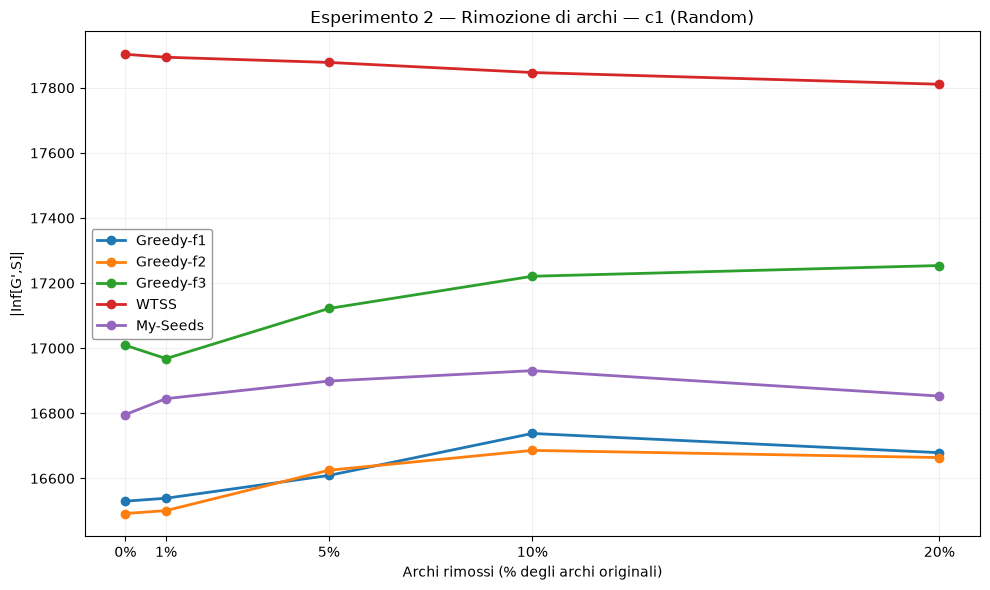

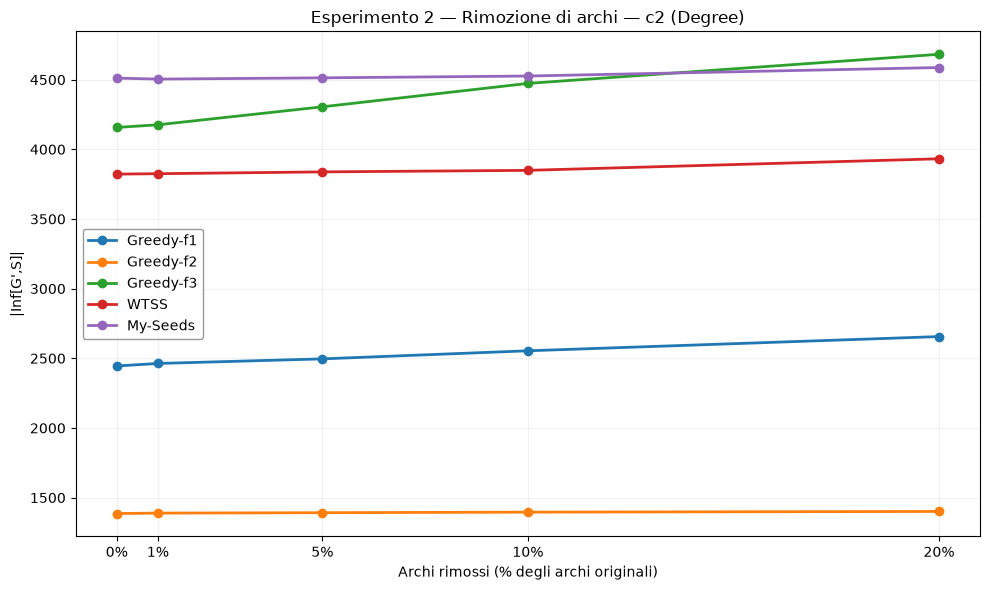

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "legend.facecolor": "white",
    "legend.edgecolor": "gray",
})

# ============================================================
# GRAFICI ESPERIMENTO 2 — Rimozione casuale di archi
# ============================================================

results_exp2 = pd.read_csv("results/results_experiment2.csv")

algorithm_order = [
    "Greedy-f1",
    "Greedy-f2",
    "Greedy-f3",
    "WTSS",
    "My-Seeds"
]

cost_titles = {
    "c1_random": "Esperimento 2 — Rimozione di archi — c1 (Random)",
    "c2_degree": "Esperimento 2 — Rimozione di archi — c2 (Degree)"
}

removal_ticks = [0, 1, 5, 10, 20]


for cost_name in ["c1_random", "c2_degree"]:

    df_cost = results_exp2[
        results_exp2["cost_function"] == cost_name
    ]

    plt.figure(figsize=(10, 6))

    for algorithm in algorithm_order:

        df_alg = df_cost[
            df_cost["algorithm"] == algorithm
        ].sort_values("edge_removal_percentage")

        # ----------------------------------------------------
        # Punto 0%: prestazione originale sull'intero grafo
        # ----------------------------------------------------
        original_influence = df_alg["influenced_original"].iloc[0]

        x = [0] + list(df_alg["edge_removal_percentage"] * 100)
        y = [original_influence] + list(df_alg["influenced_after_removal"])

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=algorithm
        )

    plt.title(cost_titles[cost_name])
    plt.xlabel("Archi rimossi (% degli archi originali)")
    plt.ylabel("|Inf[G',S]|")

    plt.xticks(
        removal_ticks,
        [f"{x}%" for x in removal_ticks]
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"results/experiment2_{cost_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

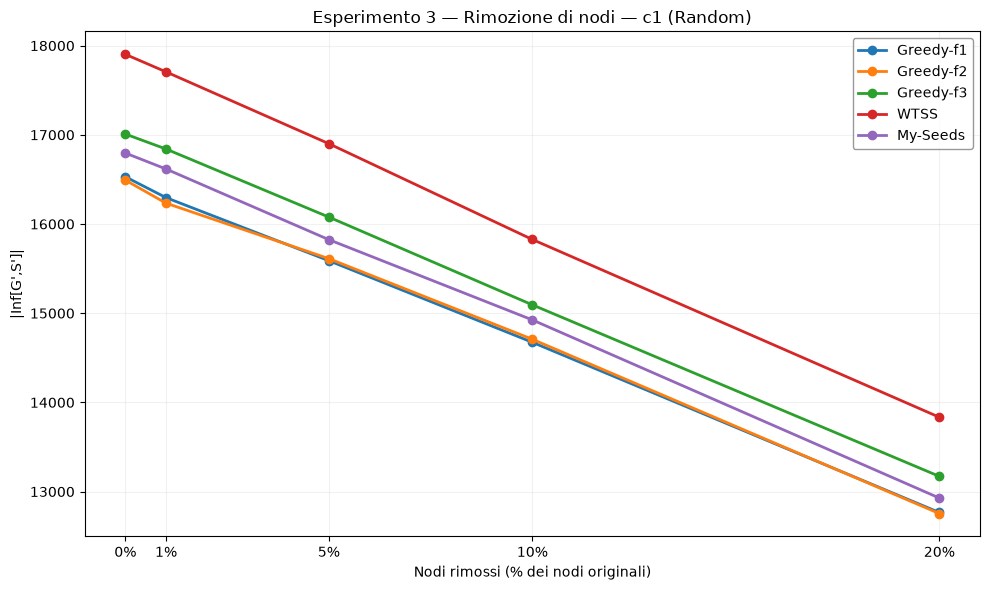

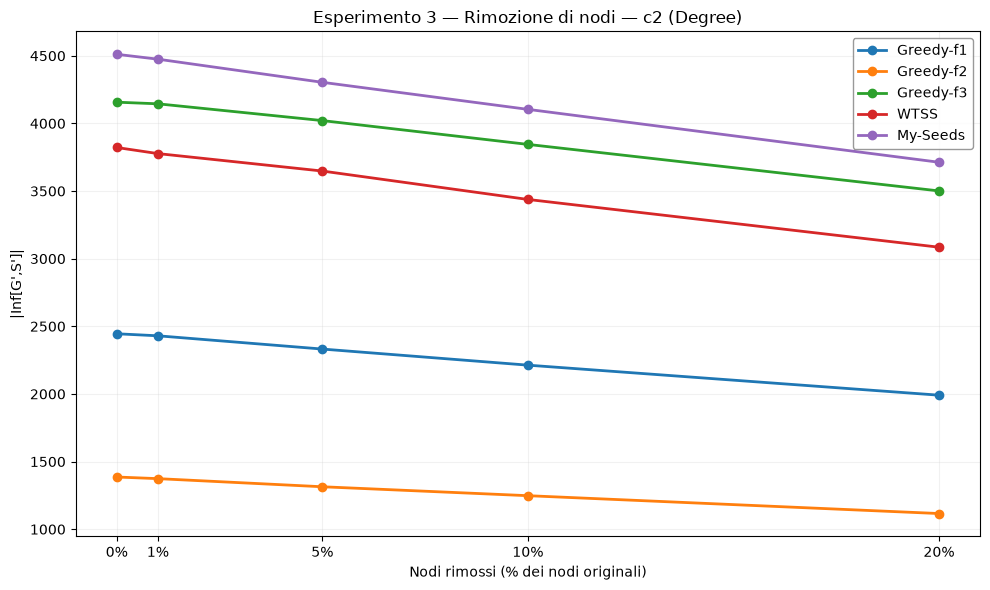

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "legend.facecolor": "white",
    "legend.edgecolor": "gray",
})
# ============================================================
# GRAFICI ESPERIMENTO 3 — Rimozione casuale di nodi
# ============================================================

results_exp3 = pd.read_csv("results/results_experiment3.csv")

algorithm_order = [
    "Greedy-f1",
    "Greedy-f2",
    "Greedy-f3",
    "WTSS",
    "My-Seeds"
]

cost_titles = {
    "c1_random": "Esperimento 3 — Rimozione di nodi — c1 (Random)",
    "c2_degree": "Esperimento 3 — Rimozione di nodi — c2 (Degree)"
}

removal_ticks = [0, 1, 5, 10, 20]


for cost_name in ["c1_random", "c2_degree"]:

    df_cost = results_exp3[
        results_exp3["cost_function"] == cost_name
    ]

    plt.figure(figsize=(10, 6))

    for algorithm in algorithm_order:

        df_alg = df_cost[
            df_cost["algorithm"] == algorithm
        ].sort_values("node_removal_percentage")

        # ----------------------------------------------------
        # Punto 0%: prestazione originale
        # ----------------------------------------------------
        original_influence = df_alg["influenced_original"].iloc[0]

        x = [0] + list(df_alg["node_removal_percentage"] * 100)
        y = [original_influence] + list(df_alg["influenced_after_removal"])

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=algorithm
        )

    plt.title(cost_titles[cost_name])
    plt.xlabel("Nodi rimossi (% dei nodi originali)")
    plt.ylabel("|Inf[G',S']|")

    plt.xticks(
        removal_ticks,
        [f"{x}%" for x in removal_ticks]
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        f"results/experiment3_{cost_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [6]:
import pandas as pd
import json
import math

# ============================================================
# ANALISI AGGIUNTIVA ESPERIMENTO 3
# Effetti strutturali e robustezza alla rimozione di nodi
# ============================================================

exp3 = pd.read_csv("results/results_experiment3.csv")


# ------------------------------------------------------------
# 1. Dati strutturali del grafo originale
# ------------------------------------------------------------

original_node_count = G_lcc.number_of_nodes()
original_edge_count = G_lcc.number_of_edges()

original_degree = dict(G_lcc.degree())

original_threshold = {
    v: math.ceil(original_degree[v] / 2)
    for v in G_lcc.nodes()
}

original_avg_degree = (
    sum(original_degree.values()) / original_node_count
)

original_avg_threshold = (
    sum(original_threshold.values()) / original_node_count
)


structural_rows = []


# ------------------------------------------------------------
# Punto 0% — grafo originale
# ------------------------------------------------------------

structural_rows.append({
    "removed_nodes_percentage": 0.0,
    "removed_nodes": 0,
    "remaining_nodes": original_node_count,
    "remaining_edges": original_edge_count,

    "average_degree": original_avg_degree,
    "average_threshold": original_avg_threshold,

    "nodes_threshold_decreased": 0,
    "threshold_decreased_percentage": 0.0,

    "number_of_components":
        nx.number_connected_components(G_lcc),

    "largest_component_size":
        original_node_count,

    "largest_component_percentage":
        100.0
})


# ------------------------------------------------------------
# 2. Ricostruzione dei grafi perturbati
#
# Basta una riga per percentuale, perché i nodi rimossi sono
# gli stessi per tutti gli algoritmi e per entrambe le funzioni
# di costo.
# ------------------------------------------------------------

perturbations = (
    exp3
    .sort_values("node_removal_percentage")
    .drop_duplicates(subset="node_removal_percentage")
)


for _, row in perturbations.iterrows():

    percentage = row["node_removal_percentage"]

    removed_nodes = set(
        json.loads(row["removed_node_list"])
    )

    G_removed = G_lcc.copy()
    G_removed.remove_nodes_from(removed_nodes)

    remaining_nodes = G_removed.number_of_nodes()
    remaining_edges = G_removed.number_of_edges()

    # --------------------------------------------------------
    # Grado e soglia dei nodi sopravvissuti
    # --------------------------------------------------------

    new_degree = dict(G_removed.degree())

    new_threshold = {
        v: math.ceil(new_degree[v] / 2)
        for v in G_removed.nodes()
    }

    avg_degree = (
        sum(new_degree.values()) / remaining_nodes
    )

    avg_threshold = (
        sum(new_threshold.values()) / remaining_nodes
    )

    # --------------------------------------------------------
    # Quanti nodi sopravvissuti hanno una soglia più bassa
    # rispetto al grafo originale
    # --------------------------------------------------------

    nodes_threshold_decreased = sum(
        1
        for v in G_removed.nodes()
        if new_threshold[v] < original_threshold[v]
    )

    threshold_decreased_percentage = (
        nodes_threshold_decreased
        / remaining_nodes
        * 100
    )

    # --------------------------------------------------------
    # Frammentazione
    # --------------------------------------------------------

    n_components = nx.number_connected_components(G_removed)

    largest_component_size = max(
        len(component)
        for component in nx.connected_components(G_removed)
    )

    largest_component_percentage = (
        largest_component_size
        / remaining_nodes
        * 100
    )

    structural_rows.append({
        "removed_nodes_percentage":
            percentage * 100,

        "removed_nodes":
            len(removed_nodes),

        "remaining_nodes":
            remaining_nodes,

        "remaining_edges":
            remaining_edges,

        "average_degree":
            avg_degree,

        "average_threshold":
            avg_threshold,

        "nodes_threshold_decreased":
            nodes_threshold_decreased,

        "threshold_decreased_percentage":
            threshold_decreased_percentage,

        "number_of_components":
            n_components,

        "largest_component_size":
            largest_component_size,

        "largest_component_percentage":
            largest_component_percentage
    })


# ------------------------------------------------------------
# 3. Tabella strutturale
# ------------------------------------------------------------

structural_exp3 = pd.DataFrame(structural_rows)

columns_to_round = [
    "average_degree",
    "average_threshold",
    "threshold_decreased_percentage",
    "largest_component_percentage"
]

structural_exp3[columns_to_round] = (
    structural_exp3[columns_to_round].round(3)
)

print("\nEFFETTI STRUTTURALI DELLA RIMOZIONE DI NODI\n")

display(
    structural_exp3[
        [
            "removed_nodes_percentage",
            "removed_nodes",
            "remaining_nodes",
            "remaining_edges",
            "average_degree",
            "average_threshold",
            "nodes_threshold_decreased",
            "threshold_decreased_percentage",
            "number_of_components",
            "largest_component_size",
            "largest_component_percentage"
        ]
    ]
)


# ============================================================
# 4. ANALISI DEI SEED E DELLA DIFFUSIONE
# ============================================================

# Percentuale del seed set originale ancora disponibile
exp3["seed_survival_percentage"] = (
    exp3["surviving_seed_size"]
    / exp3["original_seed_size"]
    * 100
)

# Percentuale della diffusione originale ancora conservata
exp3["influence_retention_percentage"] = (
    exp3["influenced_after_removal"]
    / exp3["influenced_original"]
    * 100
)

# Percentuale dei nodi ANCORA PRESENTI raggiunta dalla cascata
exp3["remaining_network_coverage"] = (
    exp3["influenced_after_removal"]
    / exp3["remaining_nodes"]
    * 100
)


# ------------------------------------------------------------
# Seed sopravvissuti
# ------------------------------------------------------------

seed_survival_table = exp3.pivot_table(
    index=["cost_function", "algorithm"],
    columns="node_removal_label",
    values="seed_survival_percentage"
).round(2)

print("\nSOPRAVVIVENZA DEL SEED SET (%)\n")

display(seed_survival_table)


# ------------------------------------------------------------
# Diffusione conservata rispetto al grafo originale
# ------------------------------------------------------------

influence_retention_table = exp3.pivot_table(
    index=["cost_function", "algorithm"],
    columns="node_removal_label",
    values="influence_retention_percentage"
).round(2)

print("\nDIFFUSIONE ORIGINALE CONSERVATA (%)\n")

display(influence_retention_table)


# ------------------------------------------------------------
# Copertura della rete ancora esistente
# ------------------------------------------------------------

coverage_table = exp3.pivot_table(
    index=["cost_function", "algorithm"],
    columns="node_removal_label",
    values="remaining_network_coverage"
).round(2)

print("\nCOPERTURA DEI NODI RIMANENTI (%)\n")

display(coverage_table)


EFFETTI STRUTTURALI DELLA RIMOZIONE DI NODI



,removed_nodes_percentage,removed_nodes,remaining_nodes,remaining_edges,average_degree,average_threshold,nodes_threshold_decreased,threshold_decreased_percentage,number_of_components,largest_component_size,largest_component_percentage
0,0.0,0,17903,196972,22.004,11.257,0,0.000,1,17903,100.000
1,1.0,179,17724,193479,21.832,11.169,1683,9.496,12,17711,99.927
2,5.0,895,17008,177999,20.931,10.717,5989,35.213,72,16886,99.283
3,10.0,1790,16113,159121,19.751,10.127,8382,52.020,158,15827,98.225
4,20.0,3581,14322,125588,17.538,9.023,9790,68.356,311,13828,96.551



SOPRAVVIVENZA DEL SEED SET (%)



node_removal_label          1%    10%    20%     5%
cost_function algorithm                            
c1_random     Greedy-f1  99.05  90.40  80.49  95.21
              Greedy-f2  99.11  90.45  80.44  95.28
              Greedy-f3  99.00  90.41  80.45  95.09
              My-Seeds   98.88  89.95  79.95  94.95
              WTSS       99.14  89.68  79.69  94.94
c2_degree     Greedy-f1  99.06  89.82  80.13  94.96
              Greedy-f2  99.17  89.53  79.88  94.88
              Greedy-f3  99.10  90.10  80.05  94.97
              My-Seeds   99.15  90.49  81.14  95.23
              WTSS       98.78  89.42  79.11  94.98


DIFFUSIONE ORIGINALE CONSERVATA (%)



node_removal_label          1%    10%    20%     5%
cost_function algorithm                            
c1_random     Greedy-f1  98.58  88.77  77.23  94.31
              Greedy-f2  98.44  89.18  77.33  94.66
              Greedy-f3  99.01  88.74  77.44  94.53
              My-Seeds   98.93  88.86  76.97  94.22
              WTSS       98.90  88.40  77.27  94.40
c2_degree     Greedy-f1  99.39  90.51  81.43  95.38
              Greedy-f2  99.13  90.04  80.52  94.81
              Greedy-f3  99.71  92.49  84.22  96.73
              My-Seeds   99.20  90.98  82.31  95.41
              WTSS       98.82  89.95  80.72  95.45


COPERTURA DEI NODI RIMANENTI (%)



node_removal_label          1%    10%    20%     5%
cost_function algorithm                            
c1_random     Greedy-f1  91.94  91.07  89.14  91.66
              Greedy-f2  91.59  91.28  89.05  91.79
              Greedy-f3  95.02  93.68  91.96  94.53
              My-Seeds   93.75  92.63  90.27  93.04
              WTSS       99.90  98.23  96.59  99.37
c2_degree     Greedy-f1  13.71  13.73  13.90  13.71
              Greedy-f2   7.75   7.75   7.79   7.73
              Greedy-f3  23.39  23.86  24.44  23.64
              My-Seeds   25.25  25.47  25.93  25.31
              WTSS       21.31  21.34  21.54  21.45